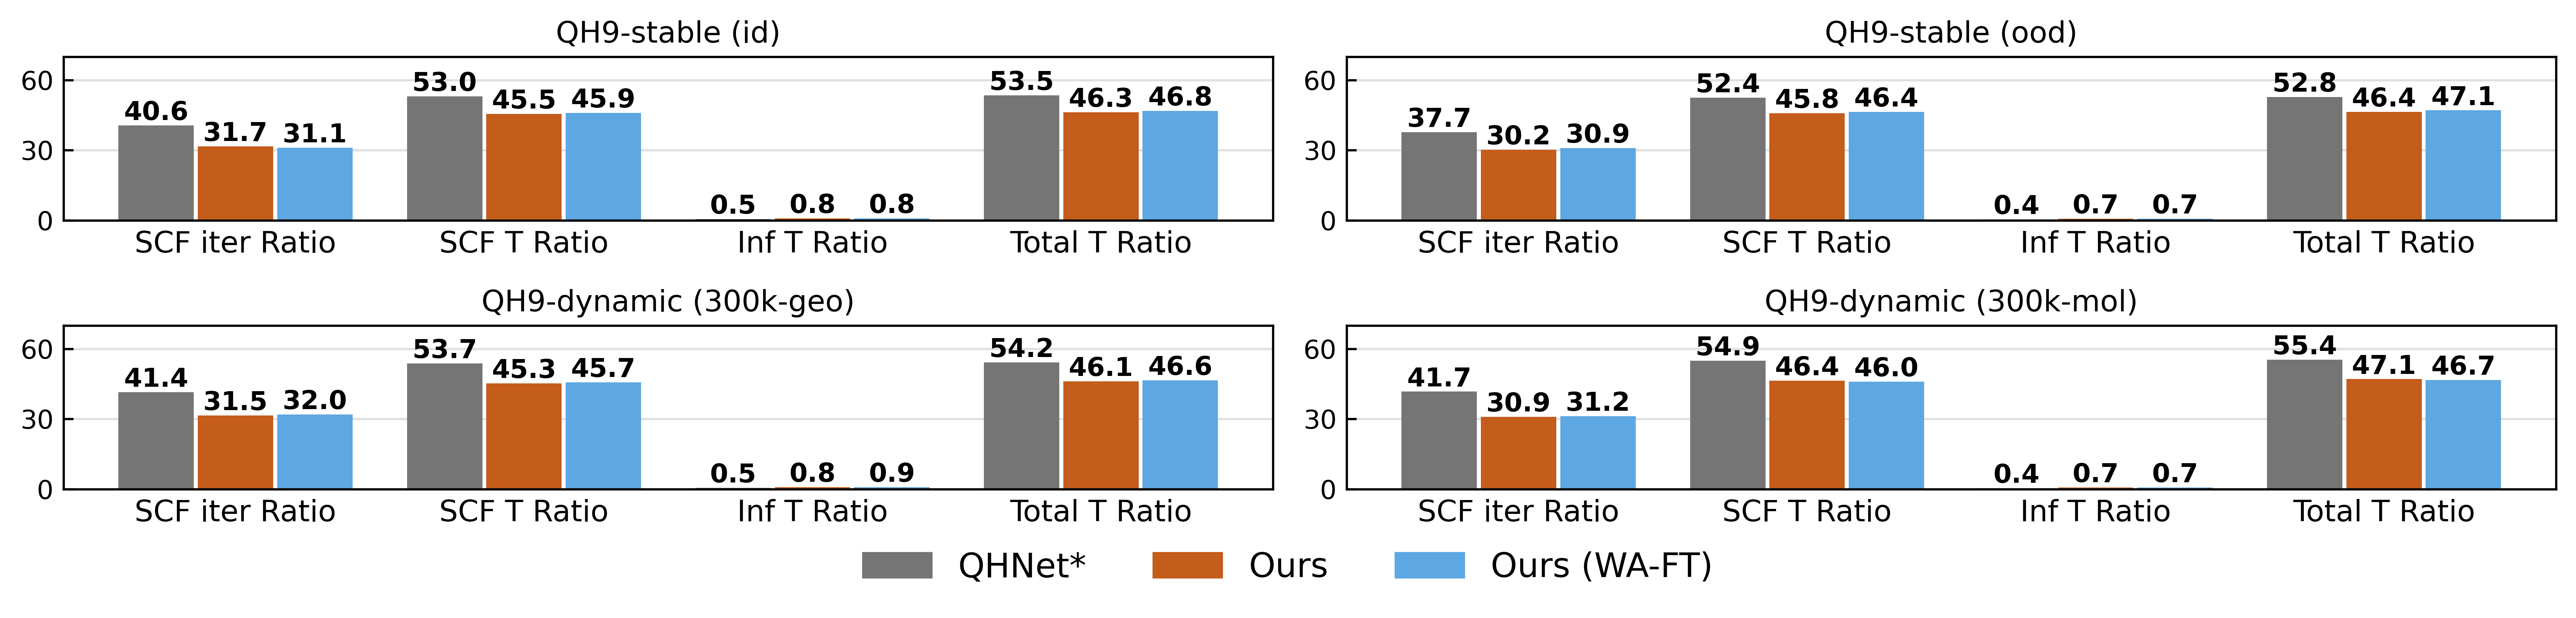

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

goodred = "#DF6B63"
goodblue = "#546BDF"
goodpurple = "#8C6CE7"
goodgreen = "#40DE66"
goodpink = "#FF9999"

# --- 1. 데이터 정의 ---
# 이미지에서 추출한 데이터입니다.
plot_data = {
    'QH9-stable (id)': {
        'SCF iter Ratio': [40.6, 31.7, 31.1],
        'SCF T Ratio': [53.0, 45.5, 45.9],
        'Inf T Ratio': [0.5, 0.8, 0.8],
        'Total T Ratio': [53.5, 46.3, 46.8]
    },
    'QH9-stable (ood)': {
        'SCF iter Ratio': [37.7, 30.2, 30.9],
        'SCF T Ratio': [52.4, 45.8, 46.4],
        'Inf T Ratio': [0.4, 0.7, 0.7],
        'Total T Ratio': [52.8, 46.4, 47.1]
    },
    'QH9-dynamic (300k-geo)': {
        'SCF iter Ratio': [41.4, 31.5, 32.0],
        'SCF T Ratio': [53.7, 45.3, 45.7],
        'Inf T Ratio': [0.5, 0.8, 0.9],
        'Total T Ratio': [54.2, 46.1, 46.6]
    },
    'QH9-dynamic (300k-mol)': {
        'SCF iter Ratio': [41.7, 30.9, 31.2],
        'SCF T Ratio': [54.9, 46.4, 46.0],
        'Inf T Ratio': [0.4, 0.7, 0.7],
        'Total T Ratio': [55.4, 47.1, 46.7]
    }
}

# 공통 설정
categories = ['SCF iter Ratio', 'SCF T Ratio', 'Inf T Ratio', 'Total T Ratio']
models = ['QHNet*', 'Ours', 'Ours (WA-FT)']
# colors = ['#6F6F6F', '#B85C31', '#6A96D2'] # [회색, 주황색, 파란색]
colors = ['#757575', '#C45C1C', '#5DA7E2']
n_groups = len(categories)
n_bars = len(models)
bar_width = 0.22  # 각 막대의 너비

# 그룹 내 막대 위치 계산
# (가운데 막대는 0, 왼쪽은 -bar_width, 오른쪽은 +bar_width)
offsets = np.linspace(-bar_width * (n_bars // 2), bar_width * (n_bars // 2), n_bars)
# [ -0.22, 0., 0.22 ] 와 유사한 값을 생성합니다. (여기서는 3개이므로)
offsets = [-bar_width, 0, bar_width] 
group_positions = np.arange(n_groups) * 0.8 # [0, 1, 2, 3]

# --- 2. 플롯 생성 ---
# 2x2 서브플롯 그리드 생성
ratio = 0.8
fig, axes = plt.subplots(2, 2, figsize=(16*ratio, 3.5*ratio))
# fig.set_size_inches(5.5, 2.5)
fig.set_dpi(600)

for ax, (title, data) in zip(axes.flat, plot_data.items()):
    
    # 각 모델(QHNet*, Ours, ...)에 대해 막대 그리기
    for i, model in enumerate(models):
        # 현재 모델에 대한 데이터 추출 (e.g., [40.6, 53.0, 0.5, 53.5])
        model_data = [data[cat][i] for cat in categories]
        
        # 막대 위치 계산 (e.g., 0-0.22, 1-0.22, 2-0.22, 3-0.22)
        pos = group_positions + offsets[i]
        
        # 막대 그리기
        rects = ax.bar(pos, model_data, bar_width*0.95, label=model, color=colors[i])
        
        # 막대 위에 값 레이블 추가
        ax.bar_label(rects, padding=0, fmt='%.1f', fontsize=9.3, fontweight='bold')

    # --- 3. 축 및 스타일 설정 ---
    ax.set_title(title, fontsize=10.5, pad=5)
    
    # y축 설정 (원본 이미지와 유사하게)
    ax.set_ylim(0, 70)
    ax.set_yticks([0, 30, 60])
    ax.tick_params(axis='y', labelsize=9.3)
    # Set minor ticks to inner
    ax.tick_params(axis='both', which='both', direction='in')
    ax.tick_params(axis='x', which='major', direction='in', size=0)
    # x축 설정
    ax.set_xticks(group_positions)
    ax.set_xticklabels(categories, fontsize=10.5)

    # 차트 테두리(spines) 및 그리드 설정
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    # ax.spines['bottom'].set_color('grey') # X축 라인
    
    # y축 그리드만 표시 (막대 뒤로 보내기)
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey', alpha=0.7)
    ax.set_axisbelow(True)

# --- 4. 공통 범례(Legend) 추가 ---
# 범례용 가상 핸들 생성
patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]

# 그림(figure) 하단 중앙에 범례 추가
fig.legend(handles=patches, 
           loc='lower center',          # 위치: 하단 중앙
           bbox_to_anchor=(0.5, -0.10),  # 정확한 위치 조정 (fig 기준 50% x, 1% y)
           ncol=3,                      # 3열로 표시
           fontsize=12, 
           frameon=False)               # 범례 테두리 없음

# --- 5. 레이아웃 조정 및 표시 ---
# 서브플롯 간 간격 및 하단 여백 조정 (범례 공간 확보)
# plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.1, hspace=0.3, wspace=0.15)
plt.tight_layout()
plt.savefig('scf_timing_new.pdf', dpi=600)
plt.show()

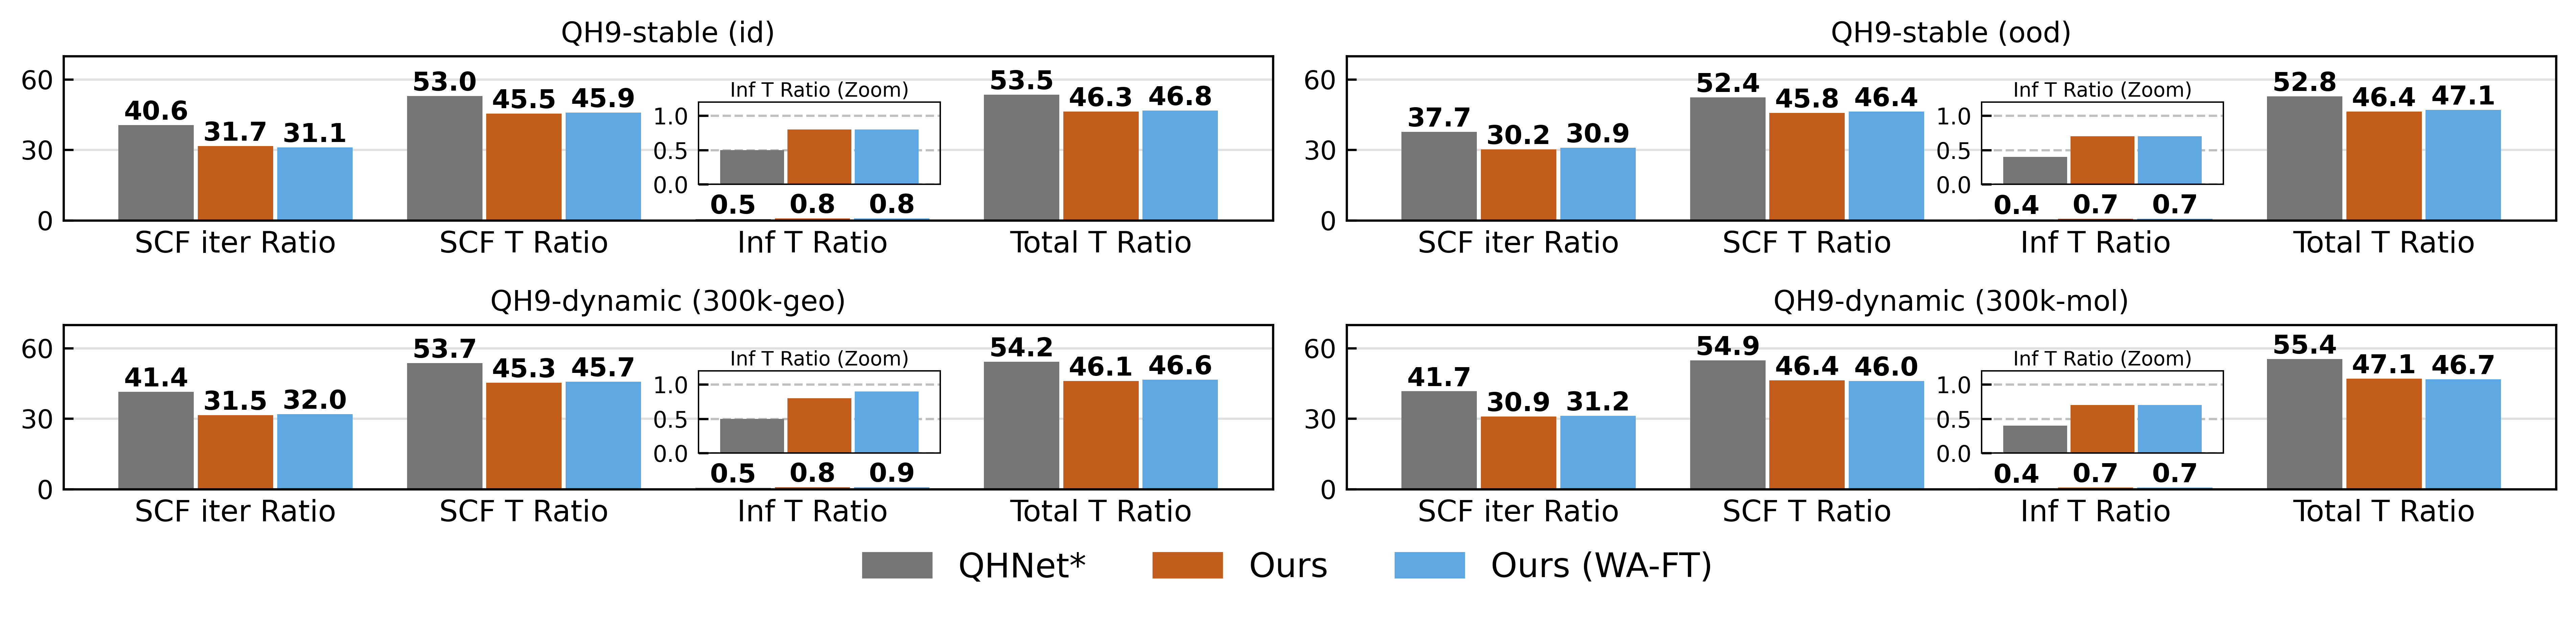

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

goodred = "#DF6B63"
goodblue = "#546BDF"
goodpurple = "#8C6CE7"
goodgreen = "#40DE66"
goodpink = "#FF9999"

# --- 1. 데이터 정의 ---
# (데이터는 원본과 동일)
plot_data = {
    'QH9-stable (id)': {
        'SCF iter Ratio': [40.6, 31.7, 31.1],
        'SCF T Ratio': [53.0, 45.5, 45.9],
        'Inf T Ratio': [0.5, 0.8, 0.8],
        'Total T Ratio': [53.5, 46.3, 46.8]
    },
    'QH9-stable (ood)': {
        'SCF iter Ratio': [37.7, 30.2, 30.9],
        'SCF T Ratio': [52.4, 45.8, 46.4],
        'Inf T Ratio': [0.4, 0.7, 0.7],
        'Total T Ratio': [52.8, 46.4, 47.1]
    },
    'QH9-dynamic (300k-geo)': {
        'SCF iter Ratio': [41.4, 31.5, 32.0],
        'SCF T Ratio': [53.7, 45.3, 45.7],
        'Inf T Ratio': [0.5, 0.8, 0.9],
        'Total T Ratio': [54.2, 46.1, 46.6]
    },
    'QH9-dynamic (300k-mol)': {
        'SCF iter Ratio': [41.7, 30.9, 31.2],
        'SCF T Ratio': [54.9, 46.4, 46.0],
        'Inf T Ratio': [0.4, 0.7, 0.7],
        'Total T Ratio': [55.4, 47.1, 46.7]
    }
}

# --- 공통 설정 (원본과 동일) ---
categories = ['SCF iter Ratio', 'SCF T Ratio', 'Inf T Ratio', 'Total T Ratio']
models = ['QHNet*', 'Ours', 'Ours (WA-FT)']
colors = ['#757575', '#C45C1C', '#5DA7E2']
n_groups = len(categories)
n_bars = len(models)
bar_width = 0.22  
offsets = [-bar_width, 0, bar_width] 
group_positions = np.arange(n_groups) * 0.8 

# --- 2. 플롯 생성 ---
ratio = 0.8
fig, axes = plt.subplots(2, 2, figsize=(16*ratio, 3.5*ratio))
fig.set_dpi(600)

for ax, (title, data) in zip(axes.flat, plot_data.items()):
    
    # --- 2.1. (원본) 메인 막대 그리기 ---
    for i, model in enumerate(models):
        model_data = [data[cat][i] for cat in categories]
        pos = group_positions + offsets[i]
        rects = ax.bar(pos, model_data, bar_width*0.95, label=model, color=colors[i])
        ax.bar_label(rects, padding=0, fmt='%.1f', fontsize=9.3, fontweight='bold')

    # --- 3. (원본) 축 및 스타일 설정 ---
    ax.set_title(title, fontsize=10, pad=5)
    ax.set_ylim(0, 70)
    ax.set_yticks([0, 30, 60])
    ax.tick_params(axis='y', labelsize=9.3)
    ax.tick_params(axis='both', which='both', direction='in')
    ax.tick_params(axis='x', which='major', direction='in', size=0)
    ax.set_xticks(group_positions)
    ax.set_xticklabels(categories, fontsize=10.5)
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey', alpha=0.7)
    ax.set_axisbelow(True)

    # --- 4. (NEW) 'Inf T Ratio'를 위한 Inset 플롯 추가 ---
    # [x, y, width, height] - 부모 ax 기준 (0~1) 좌표
    # 'Inf T Ratio'와 'Total T Ratio' 막대 위에 위치시킴
    inset_ax = ax.inset_axes([0.525, 0.22, 0.20, 0.5])
    
    # Inset에 그릴 데이터 ('Inf T Ratio' 값들)
    model_data_inset = data['Inf T Ratio']
    
    # Inset 내부에 막대 그리기
    for i, model in enumerate(models):
        inset_rects = inset_ax.bar(
            offsets[i],           # 메인 플롯과 동일한 x 오프셋 사용
            model_data_inset[i],  # 확대할 작은 값
            bar_width * 0.95,     # 동일한 막대 너비
            color=colors[i]
        )
        # Inset용 막대 레이블 (조금 더 작게)
        # inset_ax.bar_label(inset_rects, padding=1, fmt='%.1f', fontsize=7.5, fontweight='bold')

    # --- 5. (NEW) Inset 플롯 스타일링 ---
    # Y축 범위를 0~1.2 정도로 확대
    inset_ax.set_ylim(0, 1.2)
    inset_ax.set_yticks([0, 0.5, 1.0])
    inset_ax.tick_params(axis='y', labelsize=8, direction='in')
    
    # X축 범위도 막대에 맞게 조절
    inset_ax.set_xlim(-bar_width*1.8, bar_width*1.8)
    inset_ax.set_xticks([]) # X축 틱은 필요 없음

    # Inset 제목 추가
    inset_ax.set_title('Inf T Ratio (Zoom)', fontsize=7, pad=2)
    
    # Inset용 그리드
    inset_ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
    inset_ax.set_axisbelow(True)
    
    # Inset 테두리(spines) 더 얇게
    plt.setp(inset_ax.spines.values(), linewidth=0.5)


# --- 6. (원본) 공통 범례 추가 ---
patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]
fig.legend(handles=patches, 
           loc='lower center',          
           bbox_to_anchor=(0.5, -0.10),  
           ncol=3,                      
           fontsize=12, 
           frameon=False)               

# --- 7. (원본) 레이아웃 조정 및 표시 ---
plt.tight_layout()
plt.savefig('scf_timing_new_inset.pdf', dpi=600)
plt.show()